In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Your value-added results (6-digit, stream-specific)
venky_df = pd.read_csv("stream_wise_regression_m1_venky.csv")

# Saee’s value-added results (5-digit college-level)
saee_df = pd.read_stata("saee_va_30016base.dta")

# Master mapping dataset
master_df = pd.read_stata("1.5kcolleges_student&collegedetails_v2_limitedvars.dta")


In [3]:
mapping = (
    master_df[["allotted_JC_code", "coll_code_went"]]
    .dropna()
    .drop_duplicates()
)

# normalize formats
mapping["allotted_JC_code"] = mapping["allotted_JC_code"].astype(str).str.lower().str.strip()
mapping["coll_code_went"] = mapping["coll_code_went"].astype(str).str.strip()

print("Mapping rows:", mapping.shape[0])
mapping.head()


Mapping rows: 1846


,allotted_JC_code,coll_code_went
0,,54018.0
1,,56234.0
2,,56024.0
3,508402_bpc,50018.0
4,511901_mpc,42008.0


In [4]:
venky_df = venky_df.rename(columns={
    "college_code": "allotted_JC_code",
    "coef": "venky_VA_stream"
})

venky_df["allotted_JC_code"] = venky_df["allotted_JC_code"].astype(str).str.lower().str.strip()

venky_df = venky_df[["allotted_JC_code", "stream", "venky_VA_stream", "std_err"]].dropna()

print("Your VA rows:", venky_df.shape[0])
venky_df.head()


Your VA rows: 185


,allotted_JC_code,stream,venky_VA_stream,std_err
0,501602_bpc,BPC,-10.258765,4.551773
1,501802_bpc,BPC,9.150848,3.569389
2,502102_bpc,BPC,-6.875228,5.769800
3,502202_bpc,BPC,-10.680327,5.198535
4,502702_bpc,BPC,14.950612,6.799104


In [5]:
saee_df = saee_df.rename(columns={
    "coll_code": "coll_code_went",
    "VA_5": "saee_VA"
})

saee_df["coll_code_went"] = saee_df["coll_code_went"].astype(str).str.strip()

saee_df = saee_df[["coll_code_went", "saee_VA", "stderr_5"]].dropna()

print("Saee VA rows:", saee_df.shape[0])
saee_df.head()


Saee VA rows: 1722


,coll_code_went,saee_VA,stderr_5
0,30001.0,-29.354523,3.134721
1,30002.0,-16.169211,2.632412
2,30003.0,-8.752134,3.097757
3,30004.0,-8.473180,5.773027
4,30005.0,-10.023411,4.580825


In [6]:
# Step 1: your VA (6-digit) → mapping
merged = venky_df.merge(
    mapping,
    on="allotted_JC_code",
    how="left"
)

# Step 2: bring in Saee’s VA (5-digit)
merged = merged.merge(
    saee_df,
    on="coll_code_went",
    how="left"
)

print("Final merged rows:", merged.shape[0])
merged.head()


Final merged rows: 185


,allotted_JC_code,stream,venky_VA_stream,std_err,coll_code_went,saee_VA,stderr_5
0,501602_bpc,BPC,-10.258765,4.551773,33014.0,-7.202116,2.071029
1,501802_bpc,BPC,9.150848,3.569389,31016.0,-3.135446,2.201384
2,502102_bpc,BPC,-6.875228,5.769800,31014.0,-3.437104,2.233295
3,502202_bpc,BPC,-10.680327,5.198535,33023.0,-7.267071,2.296646
4,502702_bpc,BPC,14.950612,6.799104,37012.0,-2.021832,2.316556


In [7]:
print("Streams with Saee match:",
      merged["saee_VA"].notna().sum())

print("Streams without Saee match:",
      merged["saee_VA"].isna().sum())


Streams with Saee match: 185
Streams without Saee match: 0


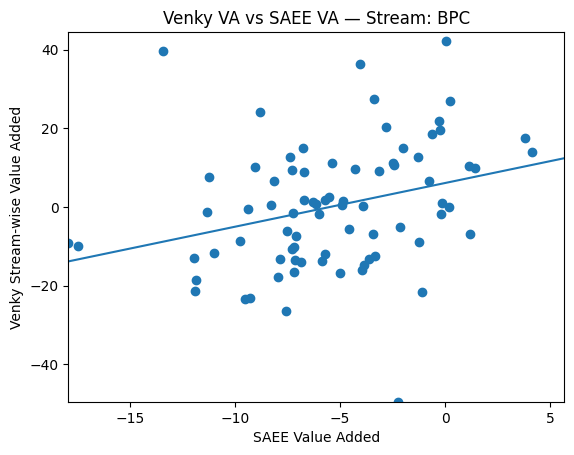

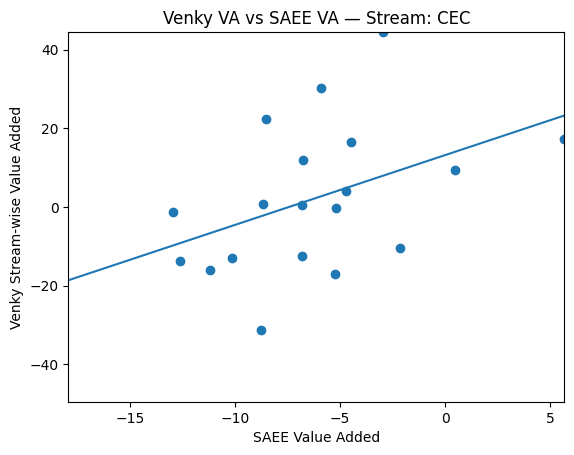

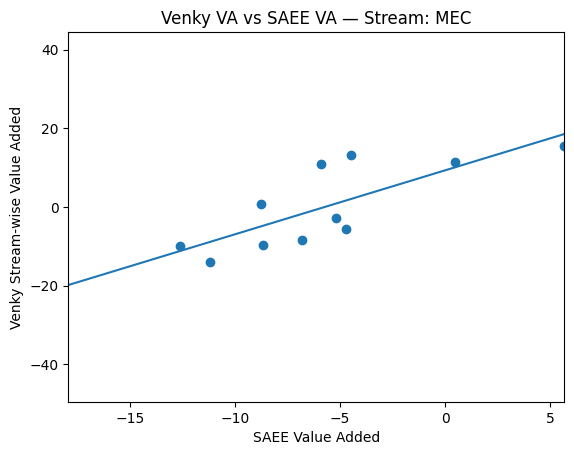

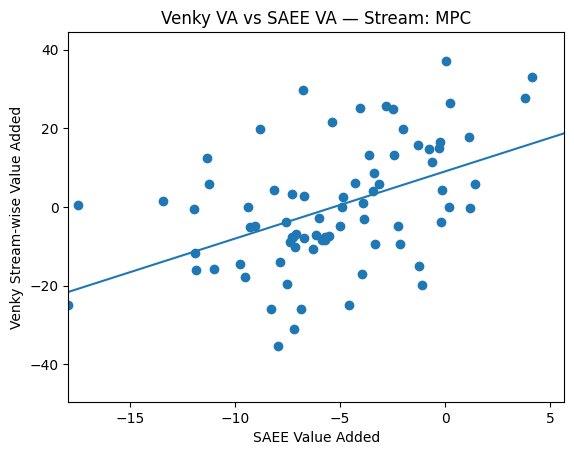

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Compute global axis limits (same scale everywhere) ---
x_min = merged["saee_VA"].min()
x_max = merged["saee_VA"].max()
y_min = merged["venky_VA_stream"].min()
y_max = merged["venky_VA_stream"].max()

streams = sorted(merged["stream"].unique())

# --- 2. Plot stream-wise ---
for stream in streams:
    df_s = merged[merged["stream"] == stream]

    x = df_s["saee_VA"].values
    y = df_s["venky_VA_stream"].values

    plt.figure()
    plt.scatter(x, y)

    # Best-fit line (OLS)
    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        x_line = np.linspace(x_min, x_max, 100)
        y_line = m * x_line + b
        plt.plot(x_line, y_line)

    plt.xlabel("SAEE Value Added")
    plt.ylabel("Venky Stream-wise Value Added")
    plt.title(f"Venky VA vs SAEE VA — Stream: {stream}")

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    plt.show()


In [13]:
venky_df_2 = pd.read_csv("venky_va_501502_bpc.csv")

In [14]:
venky_df_2.head()

,college_code,value_added,std_error,p_value
0,501601_mpc,1.190646,0.590301,0.043694
1,501602_bpc,0.840444,0.416157,0.043432
2,501801_mpc,0.504418,0.421540,0.231459
3,501802_bpc,0.894981,0.410170,0.029111
4,501903_mec,-1.930657,0.684271,0.004780


In [15]:
venky_df_2 = venky_df_2.rename(columns={
    "college_code": "allotted_JC_code",
    "value_added": "venky_VA_direct"
})

venky_df_2["allotted_JC_code"] = venky_df_2["allotted_JC_code"].astype(str).str.lower().str.strip()

venky_df_2 = venky_df_2[["allotted_JC_code", "venky_VA_direct", "std_error"]].dropna()

print("Your VA rows:", venky_df_2.shape[0])
venky_df_2.head()

Your VA rows: 192


,allotted_JC_code,venky_VA_direct,std_error
0,501601_mpc,1.190646,0.590301
1,501602_bpc,0.840444,0.416157
2,501801_mpc,0.504418,0.421540
3,501802_bpc,0.894981,0.410170
4,501903_mec,-1.930657,0.684271


In [18]:
stream_v_direct = venky_df.merge(
    venky_df_2,
    on="allotted_JC_code",
    how="inner"   # inner is correct: only colleges with both estimates
)

print("Final merged rows:", stream_v_direct.shape[0])
stream_v_direct.head()



Final merged rows: 185


,allotted_JC_code,stream,venky_VA_stream,std_err,venky_VA_direct,std_error
0,501602_bpc,BPC,-10.258765,4.551773,0.840444,0.416157
1,501802_bpc,BPC,9.150848,3.569389,0.894981,0.410170
2,502102_bpc,BPC,-6.875228,5.769800,0.253836,0.404114
3,502202_bpc,BPC,-10.680327,5.198535,-3.880314,0.604999
4,502702_bpc,BPC,14.950612,6.799104,3.423504,0.742586


In [19]:
x_min = stream_v_direct["venky_VA_direct"].min()
x_max = stream_v_direct["venky_VA_direct"].max()
y_min = stream_v_direct["venky_VA_stream"].min()
y_max = stream_v_direct["venky_VA_stream"].max()


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


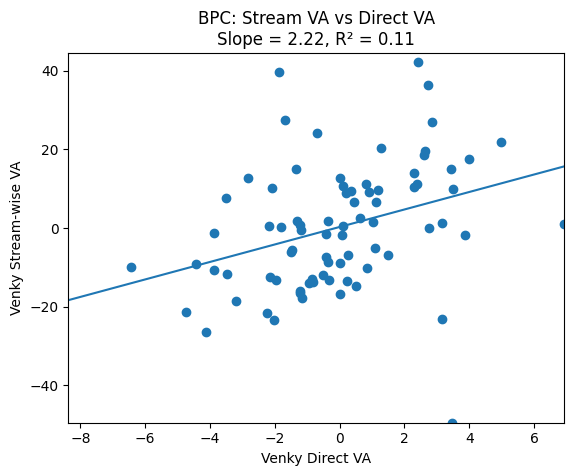

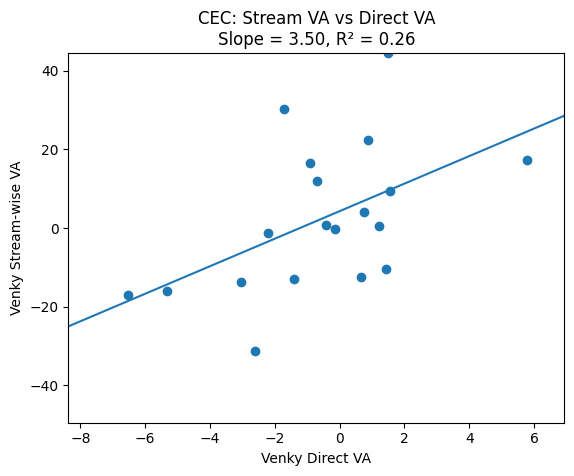

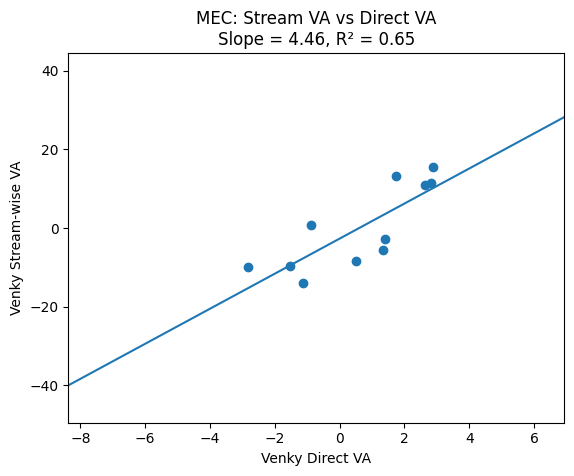

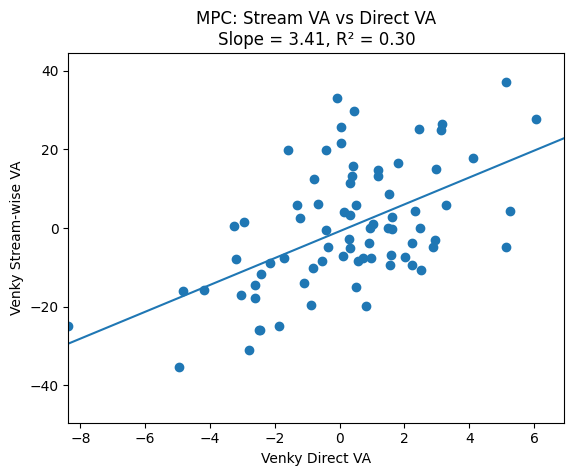

In [23]:
streams = sorted(stream_v_direct["stream"].unique())

for stream in streams:
    df_s = stream_v_direct[stream_v_direct["stream"] == stream]

    x = df_s["venky_VA_direct"]
    y = df_s["venky_VA_stream"]

    # OLS regression
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    # Plot
    plt.figure()
    plt.scatter(x, y)

    x_line = np.linspace(x_min, x_max, 100)
    y_line = model.params["const"] + model.params["venky_VA_direct"] * x_line
    plt.plot(x_line, y_line)

    plt.xlabel("Venky Direct VA")
    plt.ylabel("Venky Stream-wise VA")
    plt.title(
        f"{stream}: Stream VA vs Direct VA\n"
        f"Slope = {model.params['venky_VA_direct']:.2f}, "
        f"R² = {model.rsquared:.2f}"
    )

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    plt.show()
